In [1]:
from IPython.core.display import display, HTML
display(HTML("<style>div.output_area pre {white-space: pre;}</style>"))

In [2]:
from pyspark.sql.functions import *
from pyspark.sql.window import Window
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [3]:
df_logs = spark.read.parquet("/user/tec_sis6/memory-errors").filter(~(col("msg").like("%HANDLING MCE MEMORY ERROR%")))

In [4]:
df_logs.show(truncate=False)

+-------------------+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+----+-----+---+-------+
|timestamp          |msg                                                                                                                                                                                                                                                                                                                                                                                                                              |year|month|day|host   |
+-------------------+-----------------------------------------------------

In [8]:
from datetime import datetime, timedelta

fecha_inicio="20211214"
fecha_final="20211231"

fecha_inicio = datetime.strptime(fecha_inicio, "%Y%m%d")
fecha_final = datetime.strptime(fecha_final, "%Y%m%d")

while fecha_inicio <= fecha_final:
    print("fecha_inicio: {0}").format(fecha_inicio)
    fecha_inicio_str = fecha_inicio.strftime("%Y%m%d")

    print("Se lee para la fecha {0}".format(fecha_inicio_str))

    fecha_inicio += timedelta(days=1)


fecha_inicio: 2021-12-14 00:00:00
Se lee para la fecha 20211214
fecha_inicio: 2021-12-15 00:00:00
Se lee para la fecha 20211215
fecha_inicio: 2021-12-16 00:00:00
Se lee para la fecha 20211216
fecha_inicio: 2021-12-17 00:00:00
Se lee para la fecha 20211217
fecha_inicio: 2021-12-18 00:00:00
Se lee para la fecha 20211218
fecha_inicio: 2021-12-19 00:00:00
Se lee para la fecha 20211219
fecha_inicio: 2021-12-20 00:00:00
Se lee para la fecha 20211220
fecha_inicio: 2021-12-21 00:00:00
Se lee para la fecha 20211221
fecha_inicio: 2021-12-22 00:00:00
Se lee para la fecha 20211222
fecha_inicio: 2021-12-23 00:00:00
Se lee para la fecha 20211223
fecha_inicio: 2021-12-24 00:00:00
Se lee para la fecha 20211224
fecha_inicio: 2021-12-25 00:00:00
Se lee para la fecha 20211225
fecha_inicio: 2021-12-26 00:00:00
Se lee para la fecha 20211226
fecha_inicio: 2021-12-27 00:00:00
Se lee para la fecha 20211227
fecha_inicio: 2021-12-28 00:00:00
Se lee para la fecha 20211228
fecha_inicio: 2021-12-29 00:00:00
Se lee

In [6]:
expresiones = {
    "channel": r"channel:(\d+)",
    "slot": r"slot:(\d+)",
    "page": r"page:(0x[0-9a-f]+)",
    "offset": r"offset:(0x[0-9a-f]+)",
    "grain": r"grain:(\d+)",
    "syndrome": r"syndrome:(0x[0-9a-f]+)",
    "err_code": r"err_code:(0x[0-9a-f]+:0x[0-9a-f]+)",
    "SystemAddress": r"SystemAddress:(0x[0-9a-f]+)",
    "ProcessorSocketId": r"ProcessorSocketId:(0x[0-9a-f]+)",
    "MemoryControllerId": r"MemoryControllerId:(0x[0-9a-f]+)",
    "ChannelAddress": r"ChannelAddress:(0x[0-9a-f]+)",
    "ChannelId": r"ChannelId:(0x[0-9a-f]+)",
    "RankAddress": r"RankAddress:(0x[0-9a-f]+)",
    "PhysicalRankId": r"PhysicalRankId:(0x[0-9a-f]+)",
    "DimmSlotId": r"DimmSlotId:(0x[0-9a-f]+)",
    "Row": r"Row:(0x[0-9a-f]+)",
    "Column": r"Column:(0x[0-9a-f]+)",
    "Bank": r"Bank:(0x[0-9a-f]+)",
    "BankGroup": r"BankGroup:(0x[0-9a-f]+)",
    "ChipSelect": r"ChipSelect:(0x[0-9a-f]+)",
    "ChipId": r"ChipId:(0x[0-9a-f]+)",
    "cpu_info": r"on\s+(.*?)\(",
    "ce_error": r"(\d+\s+[A-Z]+\s+memory\s+\w+\s+error)"
}

# Aplicar las expresiones regulares y crear nuevas columnas
for nombre_columna, expresion_regular in expresiones.items():
    df_logs = df_logs.withColumn(nombre_columna, regexp_extract("msg", expresion_regular, 1))

df_logs = df_logs.\
withColumn("cpu_info", trim(df_logs["cpu_info"])).\
withColumn("number_ce_error", regexp_extract("ce_error", r"(\d+)", 1))

In [7]:
window_spec = Window.orderBy("timestamp")

df = df_logs.\
orderBy("timestamp"). \
withColumn("prev_timestamp", lag("timestamp").over(window_spec)). \
withColumn("row_number", row_number().over(window_spec)). \
withColumn("time_diff_seconds", (unix_timestamp("timestamp") - unix_timestamp("prev_timestamp"))). \
withColumn("time_diff_minuts", round(col("time_diff_seconds") / 60, 2)). \
filter(col("time_diff_minuts").isNotNull()).orderBy("timestamp")

# Definir la ventana
window = Window.orderBy("timestamp")

# Crear una columna que indique si el error está dentro del rango de 5 segundos respecto al error anterior
df = df.withColumn("is_new_group", when(col("time_diff_seconds") >= 5, 1).otherwise(0))

# Crear la columna de grupo acumulando la columna 'is_new_group'
df = df.withColumn("group_id", sum("is_new_group").over(window))

In [7]:
df.show(truncate=False)

+-------------------+------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+----+-----+---+-------+---------+---------+-----------+----------+----------------------+------------------------------+------------------+----+--------+------+----+------+----------+--------------+------+--------------+-----+-------+-------------+-----------------+-------------+---------+-------+---------------+-------------------+----------+-----------------+----------------+------------+--------+
|timestamp          |msg                                                                                                                                         

In [8]:
grouped_df = df.\
groupBy("group_id").\
agg(min("timestamp").alias("min_timestamp"), sum("number_ce_error").cast("integer").alias("number_ce_error"),
   count("err_code").alias("count")).\
orderBy("group_id")

In [9]:
grouped_df.show(truncate=False)

+--------+-------------------+---------------+-----+
|group_id|min_timestamp      |number_ce_error|count|
+--------+-------------------+---------------+-----+
|0       |2021-12-14 21:05:05|1              |1    |
|1       |2021-12-14 21:29:01|1              |1    |
|2       |2021-12-14 21:29:32|1              |1    |
|3       |2021-12-14 21:30:32|1              |1    |
|4       |2021-12-14 21:30:46|3              |2    |
|5       |2021-12-14 22:43:01|1              |1    |
|6       |2021-12-14 22:57:59|4              |3    |
|7       |2021-12-14 23:07:59|1              |1    |
|8       |2021-12-14 23:45:05|1              |1    |
|9       |2021-12-15 00:10:05|1              |1    |
|10      |2021-12-15 07:04:41|1              |1    |
|11      |2021-12-15 09:02:59|2              |1    |
|12      |2021-12-15 11:03:00|2              |2    |
|13      |2021-12-15 11:48:00|3              |2    |
|14      |2021-12-15 11:52:59|1              |1    |
|15      |2021-12-15 13:06:03|10             |

Vamos a ver a qué hora del día hay más errores:

In [8]:
errores_por_hora = (grouped_df
 .withColumn("hora", hour("min_timestamp"))
 .groupBy("hora").count().orderBy("hora")
)

errores_por_hora_pd = errores_por_hora.toPandas()

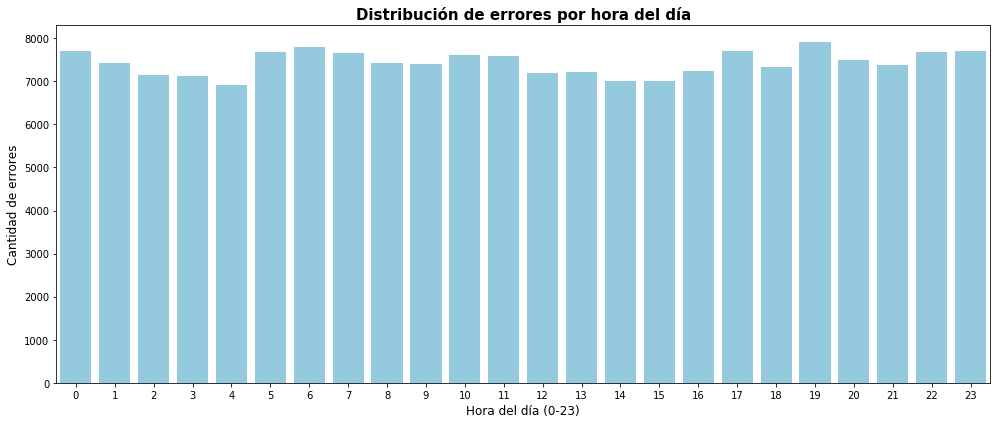

In [10]:
plt.figure(figsize=(14, 6))
sns.barplot(data=errores_por_hora_pd, x="hora", y="count", color="skyblue")
plt.xlabel(u'Hora del día (0-23)', fontsize=12)
plt.ylabel(u'Cantidad de errores', fontsize=12)
plt.title(u'Distribución de errores por hora del día', fontsize=15, weight='bold')
plt.xticks(range(0, 24))
#plt.grid(True)
plt.tight_layout()
plt.show()

Vamos a dividir por horas entre semana y fin de semana:

In [28]:
from pyspark.sql.functions import to_timestamp, hour, dayofweek, when

df_con_dia_hora = (grouped_df
                    .withColumn("hora", hour("min_timestamp"))
                    .withColumn("dia_semana", dayofweek("min_timestamp"))
                    .withColumn("tipo_dia", when((col("dia_semana") <= 5), "Semana").otherwise("Fin de semana")))

In [30]:
errores_por_hora_y_tipo = df_con_dia_hora.groupBy("hora", "tipo_dia").count()
errores_por_hora_y_tipo_pd = errores_por_hora_y_tipo.toPandas()

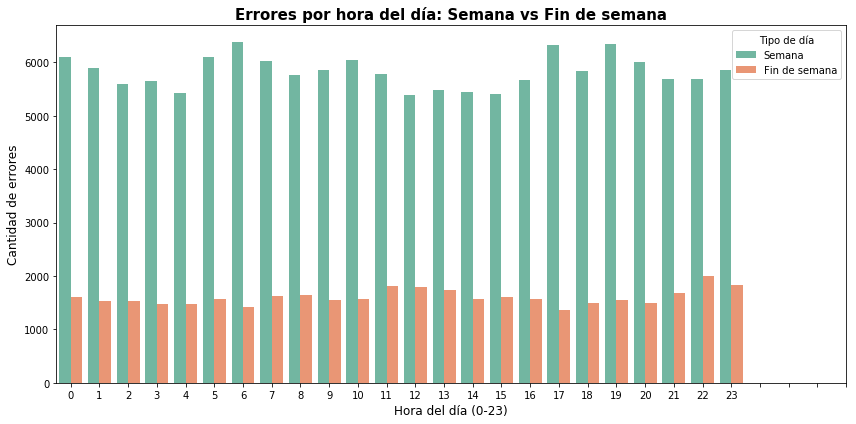

In [34]:
plt.figure(figsize=(12, 6))

# Graficar con seaborn: barras comparativas
sns.barplot(
    data=errores_por_hora_y_tipo_pd,
    x="hora",
    y="count",
    hue="tipo_dia",
    palette="Set2"
)

# Estética
plt.xlabel(u"Hora del día (0-23)", fontsize=12)
plt.ylabel(u"Cantidad de errores", fontsize=12)
plt.title(u"Errores por hora del día: Semana vs Fin de semana", fontsize=15, weight=u'bold')
plt.xticks(range(0, 28), fontsize=10)
plt.yticks(fontsize=10)
plt.legend(title=u"Tipo de día")
plt.tight_layout()
plt.show()

Vemos que es regular fin de semana y entre semana.

¿Qué día hay más fallos?

In [11]:
df_con_dia = (grouped_df
               .withColumn("dia_mes", dayofmonth("min_timestamp"))
               .withColumn(
                   "periodo_mes",
                   when(col("dia_mes") <= 10, "Inicio")
                   .when(col("dia_mes") <= 20, "Mitad")
                   .otherwise("Final")
               ))

In [12]:
errores_por_dia_mes = df_con_dia.groupBy("dia_mes").count().orderBy("dia_mes")
df_dia_mes = errores_por_dia_mes.toPandas()

errores_por_periodo = df_con_dia.groupBy("periodo_mes").count()
df_periodo = errores_por_periodo.toPandas()

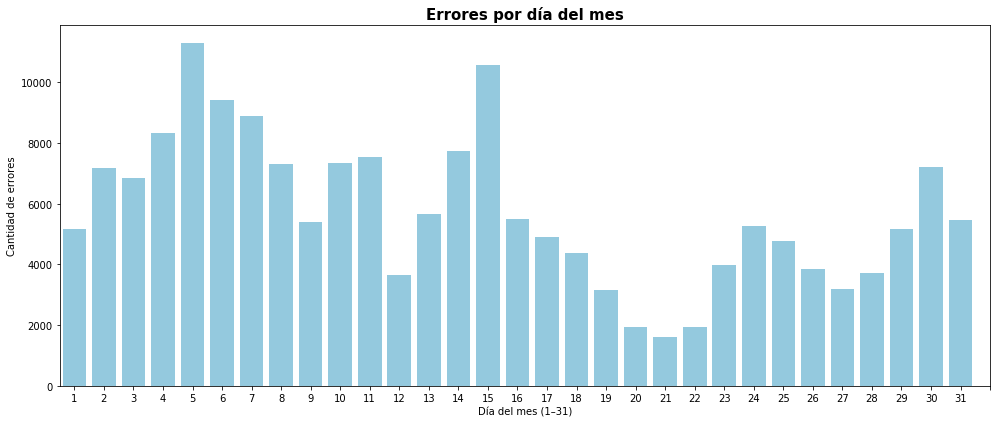

In [13]:
plt.figure(figsize=(14, 6))
sns.barplot(data=df_dia_mes, x="dia_mes", y="count", color="skyblue")
plt.title(u"Errores por día del mes", fontsize=15, weight=u'bold')
plt.xlabel(u"Día del mes (1–31)")
plt.ylabel(u"Cantidad de errores")
plt.xticks(range(0, 32))
#plt.grid(True)
plt.tight_layout()
plt.show()

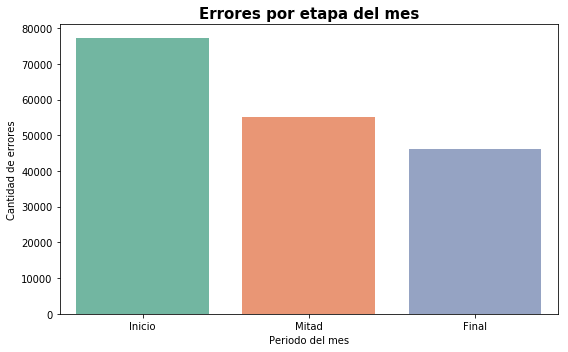

In [40]:
plt.figure(figsize=(8, 5))
sns.barplot(data=df_periodo, x="periodo_mes", y="count", palette="Set2", order=["Inicio", "Mitad", "Final"])
plt.title(u"Errores por etapa del mes", fontsize=15, weight=u'bold')
plt.xlabel(u"Periodo del mes")
plt.ylabel(u"Cantidad de errores")
plt.tight_layout()
plt.show()

Ahora vamos a ver los errores por mes:

In [47]:
df_con_mes = (grouped_df
              .withColumn("mes", month("min_timestamp"))
              .withColumn("mes_nombre", date_format("min_timestamp", "MMMM")))

errores_por_mes = df_con_mes.groupBy("mes", "mes_nombre").count().orderBy("mes")
df_mes = errores_por_mes.toPandas()

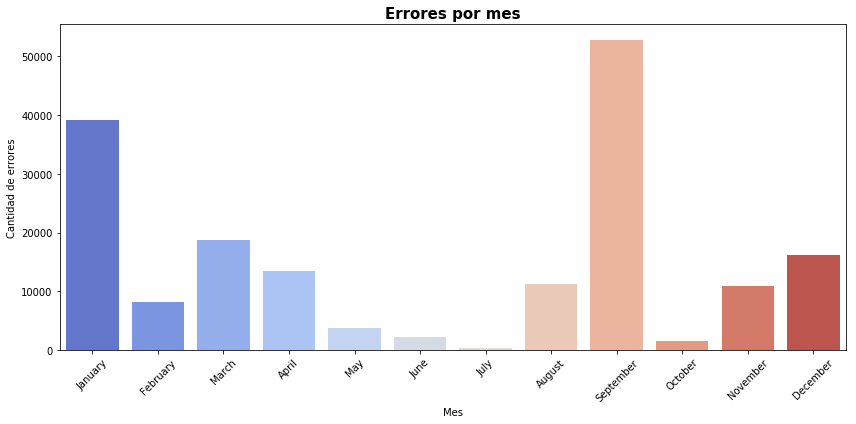

In [48]:
plt.figure(figsize=(12, 6))

# Ordenar los meses si es necesario
df_mes = df_mes.sort_values("mes")

# Gráfica
sns.barplot(data=df_mes, x="mes_nombre", y="count", palette="coolwarm")

plt.xlabel("Mes")
plt.ylabel("Cantidad de errores")
plt.title("Errores por mes", fontsize=15, weight='bold')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Como vemos lo normal es tener más logs cuando el cluster se usa, se puede observar claramente que después del verano el cluster se carga y cuando es invierno el cluster también se usa. Y por otro lado, en verano no hay muchos errores ya que no hay mucha gente trabajando.

### Vamos a ver la estacionalidad

In [49]:
df_con_fecha = grouped_df.withColumn("fecha", to_date(to_timestamp("min_timestamp")))
errores_diarios = df_con_fecha.groupBy("fecha").count().orderBy("fecha")

errores_diarios_pd = errores_diarios.toPandas()
errores_diarios_pd = errores_diarios_pd.sort_values("fecha")
errores_diarios_pd.set_index("fecha", inplace=True)

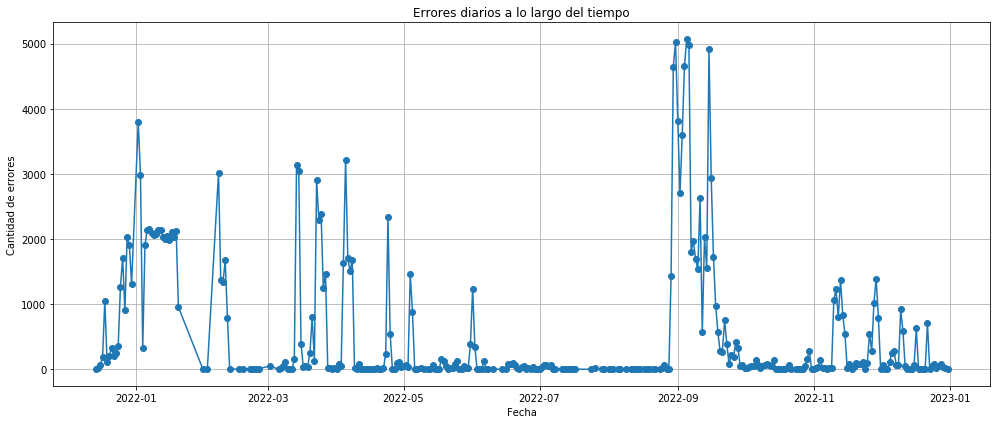

In [50]:
plt.figure(figsize=(14, 6))
plt.plot(errores_diarios_pd.index, errores_diarios_pd['count'], marker='o', linestyle='-')
plt.title(u"Errores diarios a lo largo del tiempo")
plt.xlabel(u"Fecha")
plt.ylabel(u"Cantidad de errores")
plt.grid(True)
plt.tight_layout()
plt.show()

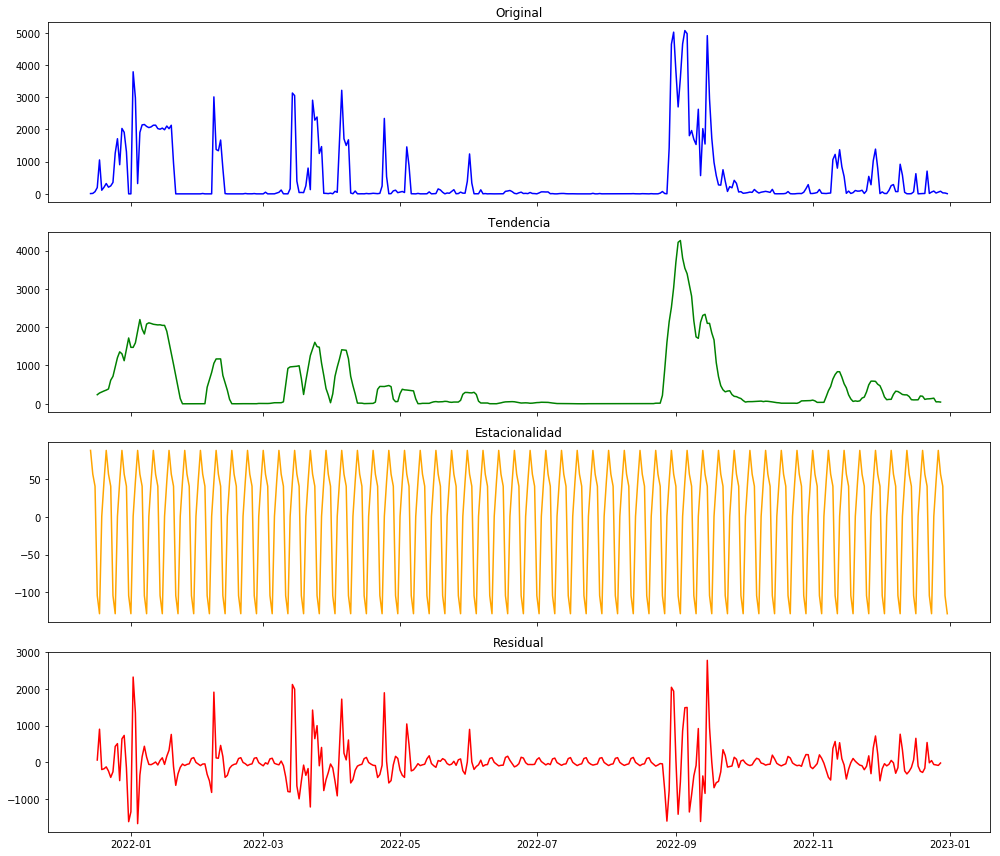

In [64]:
from statsmodels.tsa.seasonal import seasonal_decompose

serie = errores_diarios_pd['count'].asfreq('D').fillna(0)

# Descomponer
resultado = seasonal_decompose(serie, model='additive', freq=7)  # o period=30 para mensual

trend = resultado.trend
seasonal = resultado.seasonal
residual = resultado.resid

fig, axs = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

axs[0].plot(serie, label='Original', color='blue')
axs[0].set_title("Original")
axs[1].plot(trend, label='Tendencia', color='green')
axs[1].set_title("Tendencia")
axs[2].plot(seasonal, label='Estacionalidad', color='orange')
axs[2].set_title("Estacionalidad")
axs[3].plot(residual, label='Ruido', color='red')
axs[3].set_title("Residual")

plt.tight_layout()
plt.show()

## Heatmap

In [10]:
df_heat = (grouped_df
           .withColumn("hora", hour("min_timestamp"))
           .withColumn("dia_semana", date_format("min_timestamp", "E")))

errores_por_dia_hora = df_heat.groupBy("dia_semana", "hora").count()
errores_por_dia_hora_pd = errores_por_dia_hora.toPandas()

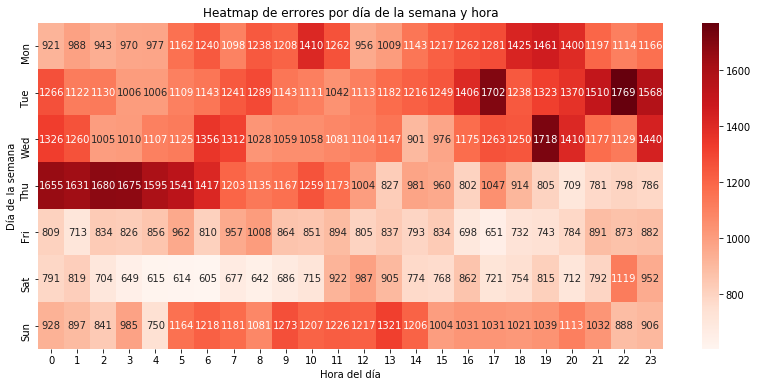

In [12]:
dias_orden = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
errores_pivot = errores_por_dia_hora_pd.pivot_table(
    index="dia_semana", columns="hora", values="count", fill_value=0
).reindex(dias_orden)

plt.figure(figsize=(14, 6))
sns.heatmap(errores_pivot, cmap="Reds", annot=True, fmt="d")
plt.title(u"Heatmap de errores por día de la semana y hora")
plt.xlabel(u"Hora del día")
plt.ylabel(u"Día de la semana")
plt.show()